**IMDB Binary Text Classification:**

**Project Description:**

This project contains 25,000 movie reviews for training and 25,000 movie reviews for testing. Its a binary sentiment classification dataset for classifying the IMDB reviews.

**Project Objective:**

The main objective of the project is to classify whether a review is positive or negative. I have used the following deep learning models to classify the sentiment of a review. I have chosen the best model based on the accuracy and loss values, and implemented the best model on the test set. Have also hyperparameter tuning for BiLSTM, CNN, and GRU models.

1. Baseline Model
2. BiLSTM
3. BiLSTM Tuned
4. CNN
5. CNN Tuned
6. GRU
7. GRU Tuned

**Data Description:**

This dataset has reviews and a label (0 or 1 ) to indicate if they are positive or negative.

0-Negative
1-Positive

Reviews in the dataset:
25000 - Train
25000 - Test

I have split the 25000 reveiws ib the train folder to 20000 for traning and 5000 for validation.

Each review is in a separate file.

In [4]:
!nvidia-smi

Sun Feb 22 05:12:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             29W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os

!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  12.5M      0  0:00:06  0:00:06 --:--:-- 7847k


In [6]:
!tar -xzf aclImdb_v1.tar.gz

In [7]:
!ls

aclImdb  aclImdb_v1.tar.gz


In [8]:
!ls aclImdb/train

labeledBow.feat  pos	unsupBow.feat  urls_pos.txt
neg		 unsup	urls_neg.txt   urls_unsup.txt


In [9]:
!ls aclImdb/test

labeledBow.feat  neg  pos  urls_neg.txt  urls_pos.txt


In [10]:
!cat aclImdb/train/pos/6248_7.txt

Being an Austrian myself this has been a straight knock in my face. Fortunately I don't live nowhere near the place where this movie takes place but unfortunately it portrays everything that the rest of Austria hates about Viennese people (or people close to that region). And it is very easy to read that this is exactly the directors intention: to let your head sink into your hands and say "Oh my god, how can THAT be possible!". No, not with me, the (in my opinion) totally exaggerated uncensored swinger club scene is not necessary, I watch porn, sure, but in this context I was rather disgusted than put in the right context.<br /><br />This movie tells a story about how misled people who suffer from lack of education or bad company try to survive and live in a world of redundancy and boring horizons. A girl who is treated like a whore by her super-jealous boyfriend (and still keeps coming back), a female teacher who discovers her masochism by putting the life of her super-cruel "lover" 

In [11]:
!rm -r aclImdb/train/unsup

In [12]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers

from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding,GRU,Dense,Bidirectional
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import keras_tuner as kt
from sklearn.metrics import roc_curve, auc

import tensorflow_hub as hub
import tensorflow_text as text

2026-02-22 05:13:17.028104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771737197.217158      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771737197.268795      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771737197.688773      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771737197.688808      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771737197.688813      55 computation_placer.cc:177] computation placer alr

In [108]:
raw_train_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='training',seed=42,shuffle=True)

raw_val_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='validation',seed=42,shuffle=False)

raw_test_ds = keras.utils.text_dataset_from_directory("aclImdb/test",batch_size=32,shuffle=False)

print("\n")
print(f"Number of batches in raw_train_ds:{raw_train_ds.cardinality()}")
print(f"Number of batches in raw_val_ds:{raw_val_ds.cardinality()}")
print(f"Number of batches in raw_test_ds:{raw_test_ds.cardinality()}")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


Number of batches in raw_train_ds:625
Number of batches in raw_val_ds:157
Number of batches in raw_test_ds:782


**Exploratory Data Analysis**

EDA is done only on the training data. Not on the validation and test set.

In [15]:
#Light Cleaning for EDA

def clean_text_light(text):
  text = re.sub(r"<br\s*/?","",text) #remove HTML tags
  text = re.sub(r"[^a-zA-Z\s]","",text) # remove punctuation and numbers
  text = re.sub(r"\s+","",text) #multiple spaces

  return text.lower().strip()

In [16]:
texts = []
labels = []

for text_batch,label_batch in raw_train_ds:
  for text,label in zip(text_batch.numpy(),label_batch.numpy()):
    texts.append(text.decode("utf-8"))
    labels.append(int(label))

In [17]:
train_df = pd.DataFrame({"review":texts,"label":labels})
train_df['clean_review'] = train_df['review'].apply(clean_text_light)
train_df.head()

,review,label,clean_review
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...


In [18]:
train_df.shape

(20000, 3)

In [19]:
train_df['label'].value_counts()

label
0    10038
1     9962
Name: count, dtype: int64

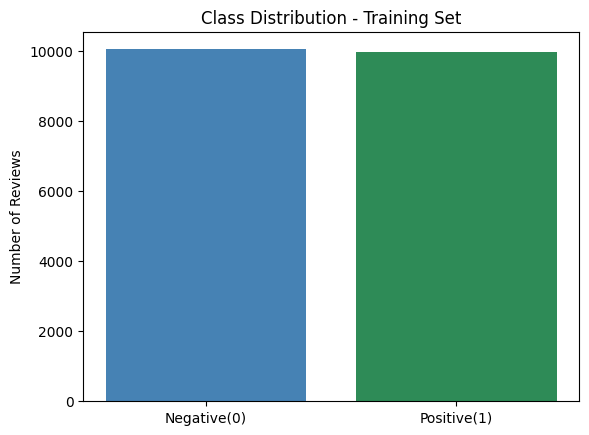



Class Percentage Distribution
0    50.19
1    49.81
dtype: float64


In [20]:
#Class Distribution:

plt.bar(['Negative(0)','Positive(1)'],[10038,9962],color=['steelblue','seagreen'])
plt.title('Class Distribution - Training Set')
plt.ylabel('Number of Reviews')

plt.show()

#Percentage distribution
print("\n")
print("Class Percentage Distribution")
counts = pd.Series({0:10038,1:9962})
percentages = counts/counts.sum() * 100

print(percentages)

We can see from the above that the class is balanced.

Negative Sentiment/Reviews - 10038
Positive Sentiment/Reviews - 9962

This confirms there is no class imbalance.

In [21]:
#Check for Missing or Empty Reviews

#Missing reviews

train_df['review'].isna().sum()

np.int64(0)

In [22]:

#Check for empty reviews or whitespaces

empty_str = (train_df['review'].str.strip()=="").sum()
print(f"There are {empty_str} empty string")

There are 0 empty string


We can conclude from the above that there are no missing values and empty reviews.

**Text Length Analysis:**
**Word/Character Count Distribution:**

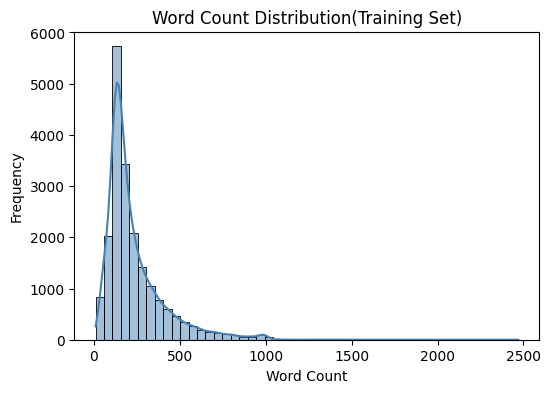

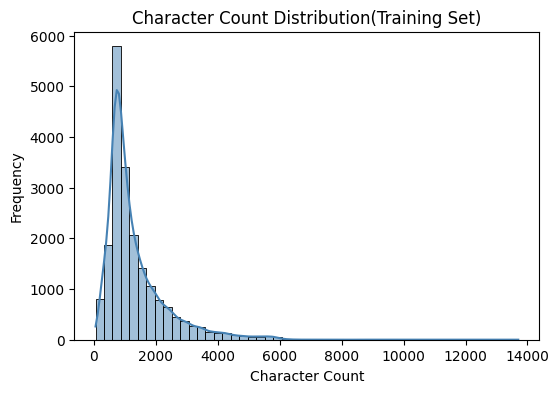

In [23]:
#Calculate Word count and character count

train_df['word_count']=train_df['review'].apply(lambda x:len(x.split()))
train_df['char_count'] = train_df['review'].apply(lambda x:len(x))

#Word Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['word_count'],bins=50,kde=True,color='steelblue')
plt.title('Word Count Distribution(Training Set)')
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#Character Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['char_count'],bins=50,kde=True,color='steelblue')
plt.title('Character Count Distribution(Training Set)')
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

From the above 2 plots, we can see that most of the reviews have 100 to 200 words.Reviews greater than 500 words are very less. This means everyone prefers to write short reviews.

The character count plot also implies the same.

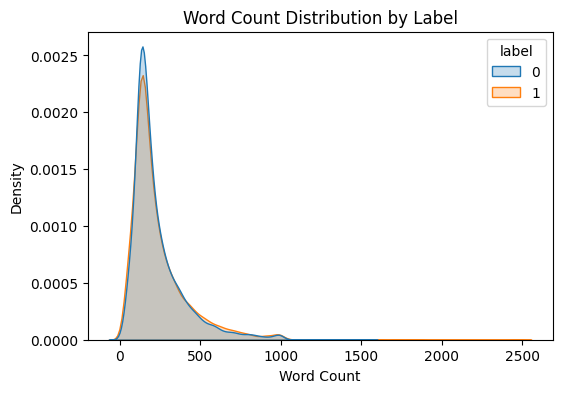

In [24]:
#Length Distributions Comparisons - Positive vs Negative reviews

plt.figure(figsize=(6,4))
sns.kdeplot(data=train_df,x='word_count',hue='label',fill=True)
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.show()

Most of the reviews whether positive or negative,are relatively short , around 200 to 400 words.Since both the curves overlap, this is not a strong review of the label(0 or 1).Very few reviews exceed 1000 words.

**Outlier Detection:**

In [25]:
#Identify Outliers

low_word_threshold = train_df['word_count'].quantile(0.01)
high_word_threshold = train_df['word_count'].quantile(0.99)

outliers_short = train_df[train_df['word_count'] <= low_word_threshold]
outliers_long = train_df[train_df['word_count'] >= high_word_threshold]

print("Very Short Reviews(bottom 1%)",outliers_short.shape[0])
print("Very long Reviews(top 1%)",outliers_long.shape[0])

print("\nExample of very short reviews")
print(outliers_short['review'].head(1).to_list())

print("\nExample of very long reviews")
print(outliers_long['review'].head(1).to_list())

Very Short Reviews(bottom 1%) 218
Very long Reviews(top 1%) 201

Example of very short reviews
['Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.']

Example of very long reviews
['I\'m going to write about this movie and about "Irreversible" (the (in)famous scene in it). So you are warned, if you haven\'t seen the movie yet. This are just my thoughts, why I think the movie fails (in the end - pun intended).<br /><br />Acting wise, Rosario Dawson is really good and almost conveys portraying someone almost a decade younger (a teenager in other words). The villain guy is good, but loses his "evil" touch right before the end. If he really never changes, then why would he let a woman tie him up? He wouldn\'t, period. Then we also have the bartender/2nd rape Dude. Actually I don\'t think you would need him. At least not for the 2nd rape, but more about that later on.<br /><br />Let\'s reprise the story. Rosario

<Figure size 1200x500 with 0 Axes>

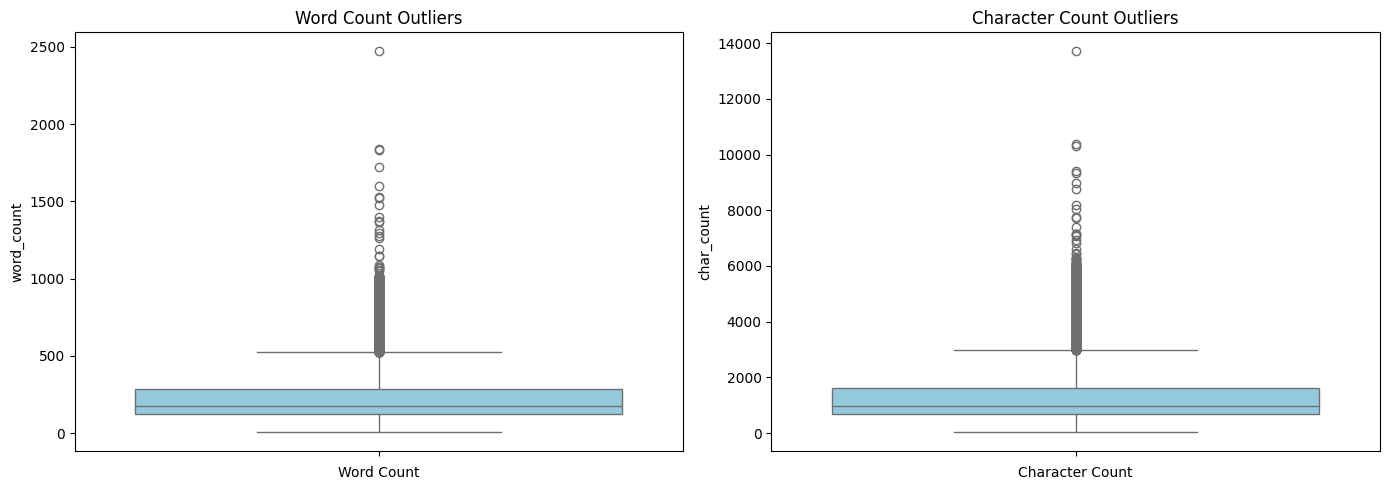

In [26]:
plt.figure(figsize=(12,5))

fig,axes = plt.subplots(1,2,figsize=(14,5))

#Word Count Boxplot
sns.boxplot(y=train_df['word_count'],ax=axes[0],color='skyblue')
axes[0].set_title("Word Count Outliers")
axes[0].set_xlabel('Word Count')

#Character Count boxplot
sns.boxplot(y=train_df['char_count'],ax=axes[1],color='skyblue')
axes[1].set_title("Character Count Outliers")
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.show()


Word Count Outlier plot reveals that most of the words were between ~50  and within ~500.Dots above the whiskers are outliers - reviews that are usually long up to 2500 words.It might have excessive repetition etc.

Character Count Outlier plot reveals the same structure like word count.Most reviews are under ~ 4000 characters.But ouliers stretch to 14000 characters. This might have html tags,punctuation etc. which will be removed during data processing.

#Vocabulary-Level EDA

/tmp/ipykernel_55/2436678500.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
/tmp/ipykernel_55/2436678500.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
/tmp/ipykernel_55/2436678500.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
/tmp/ipykernel_55/2436678500.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels()

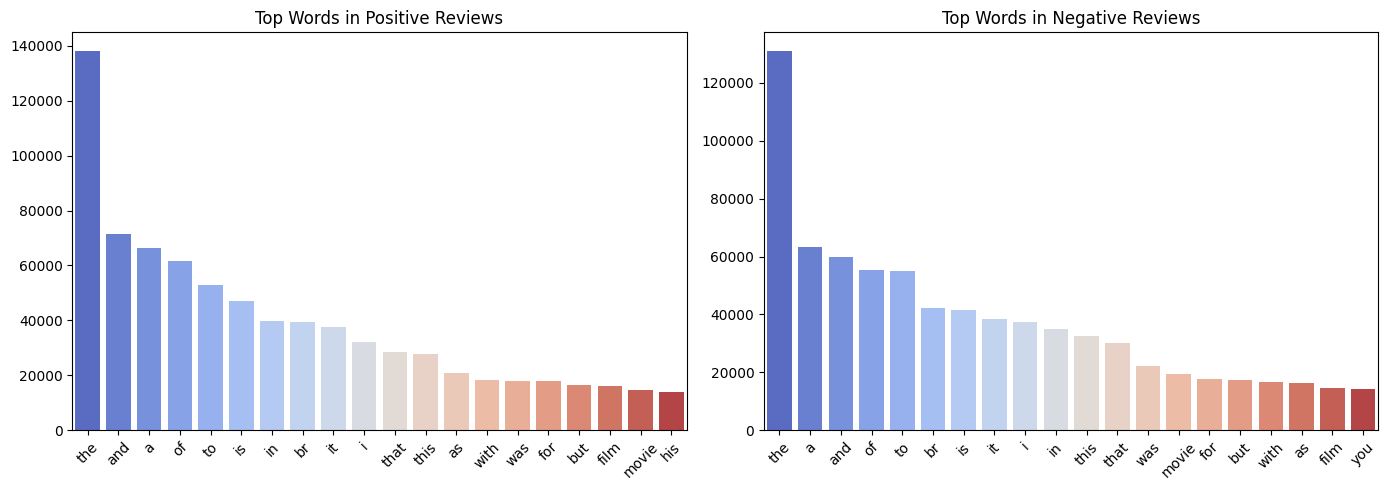

In [27]:
#Most Frequent words(raw counts)
stop_words = set(stopwords.words('english'))

def tokenize(text):
  tokens = word_tokenize(text.lower())
  tokens = [t for t in tokens if t.isalpha()]

  return tokens
train_df['tokens'] = train_df['review'].apply(tokenize)

#Frequent words per class

def get_top_words_by_class(df,label,top_n=20):
  words = [word for tokens in df[df['label']==label]['tokens']for word in tokens]
  return Counter(words).most_common(top_n)

pos_words = get_top_words_by_class(train_df,1)
neg_words = get_top_words_by_class(train_df,0)

fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax,data,title in zip(axes,[pos_words,neg_words],['Positive','Negative']):
  words,counts = zip(*data)
  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
  ax.set_title(f'Top Words in {title} Reviews')
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

plt.tight_layout()
plt.show()

This shows the top frequent 20 words in Positive and Negative reviews.

From the above 2 plots,we can see that the word 'The' has maximum count for both positive and negative reviews.

In [28]:
train_df.head()

,review,label,clean_review,word_count,char_count,tokens
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...,135,751,"[pandemonium, is, a, horror, movie, spoof, tha..."
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...,205,1180,"[david, mamet, is, a, very, interesting, and, ..."
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...,125,702,"[great, documentary, about, the, lives, of, ny..."
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...,342,1969,"[it, boggles, the, mind, how, this, movie, was..."
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...,269,1511,"[the, concept, of, the, legal, gray, area, in,..."


/tmp/ipykernel_55/1370144885.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),palette='gray')


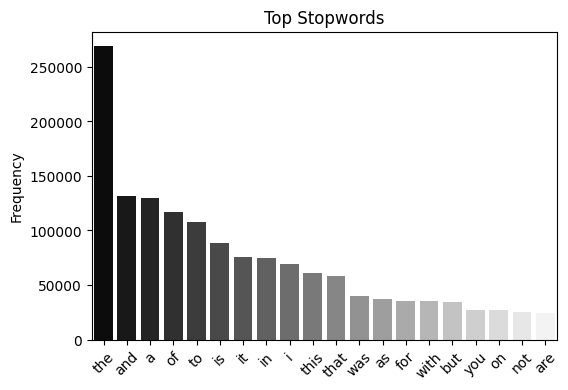

In [29]:
#Stopword Frequency

train_df['tokens']

all_words = [word for tokens in train_df['tokens'] for word in tokens]
stopword_counts = Counter([word for word in all_words if word in stop_words])
top_stopwords = stopword_counts.most_common(20)
words,counts = zip(*top_stopwords)

plt.figure(figsize=(6,4))
sns.barplot(x=list(words),y=list(counts),palette='gray')
plt.title('Top Stopwords')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

In [30]:
#Rare words count

word_freq =  [word for tokens in train_df['tokens'] for word in tokens]
word_freq_list = Counter(word_freq)

rare_words = [word for word,count in word_freq_list.items() if count==1]
print(f"Total length of rare words: {len(rare_words)}")
print(f"Total Vocabulary size:{len(word_freq)}")

Total length of rare words: 24062
Total Vocabulary size:4609286


**Word Cloud:**

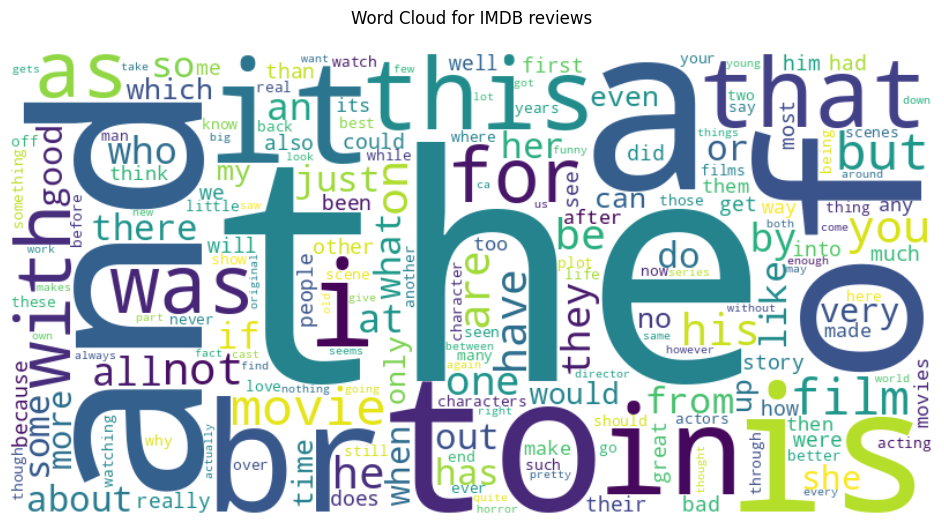

In [31]:
word_freq = Counter(all_words)

wordcloud = WordCloud(width=800,height=400,background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for IMDB reviews\n")
plt.show()


**N-grams:**

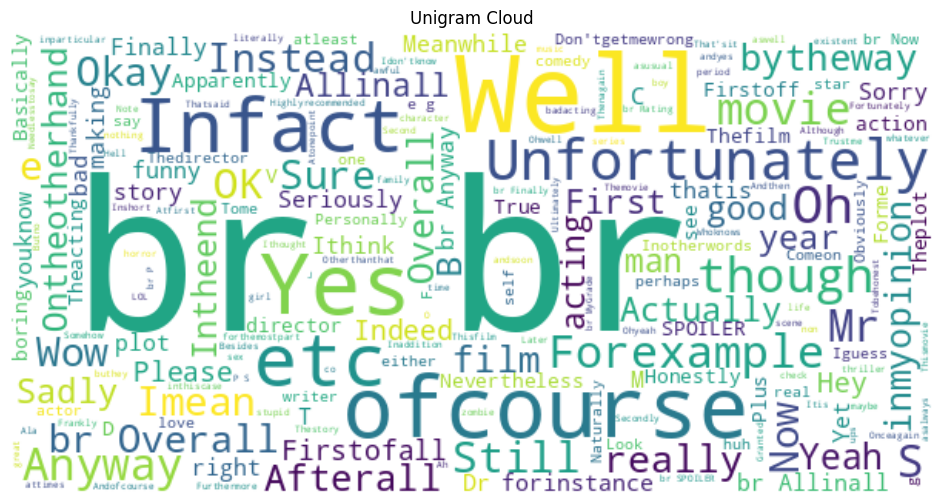

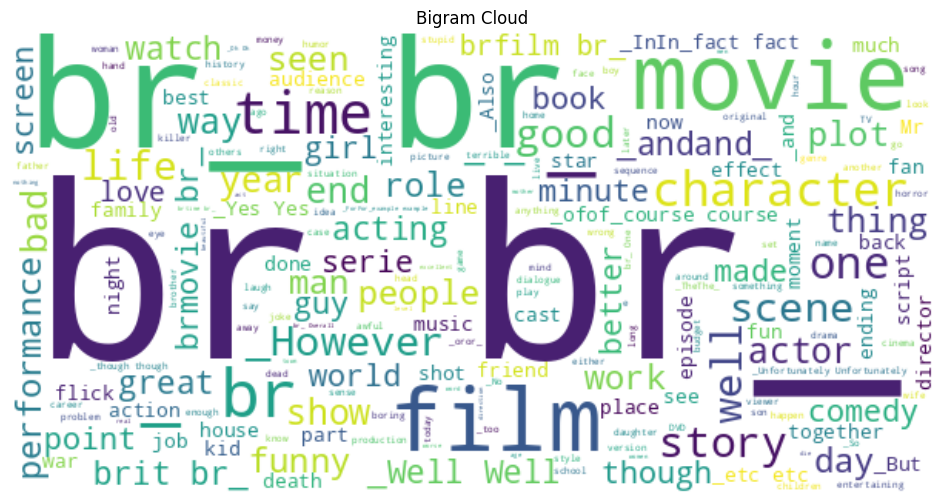

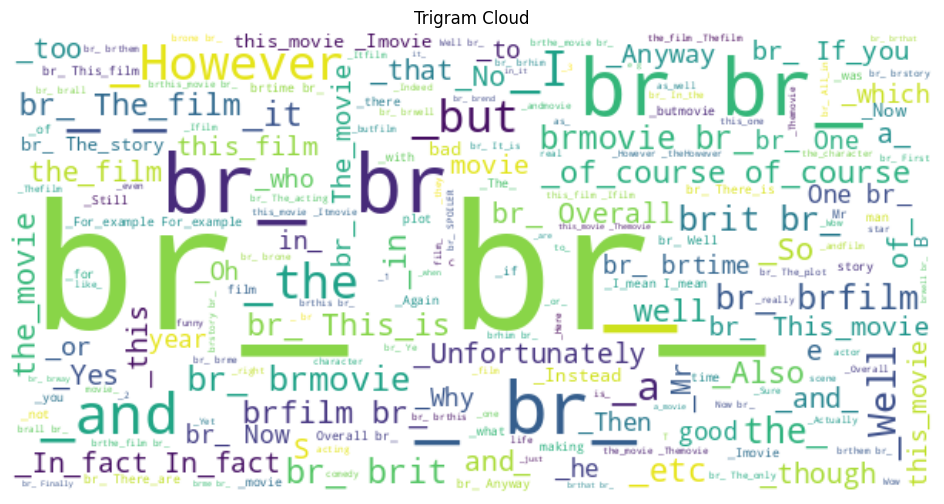

In [32]:
#N-grams for the entire training dataset

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

unigrams = generate_all_ngrams(train_df['review'],1)
bigrams = generate_all_ngrams(train_df['review'],2)
trigrams = generate_all_ngrams(train_df['review'],3)

unigram_counts = Counter(unigrams)
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

unigram_text = "".join(["_".join(u) for u in unigrams])
bigram_text = "".join(["_".join(b) for b in bigrams])
trigram_text = "".join(["_".join(t) for t in trigrams])

def show_cloud(text,title):
  wc = WordCloud(width=600,height=300,background_color='white').generate(text)
  plt.figure(figsize=(12,6))
  plt.imshow(wc,interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

show_cloud(unigram_text,"Unigram Cloud")
show_cloud(bigram_text,"Bigram Cloud")
show_cloud(trigram_text,"Trigram Cloud")

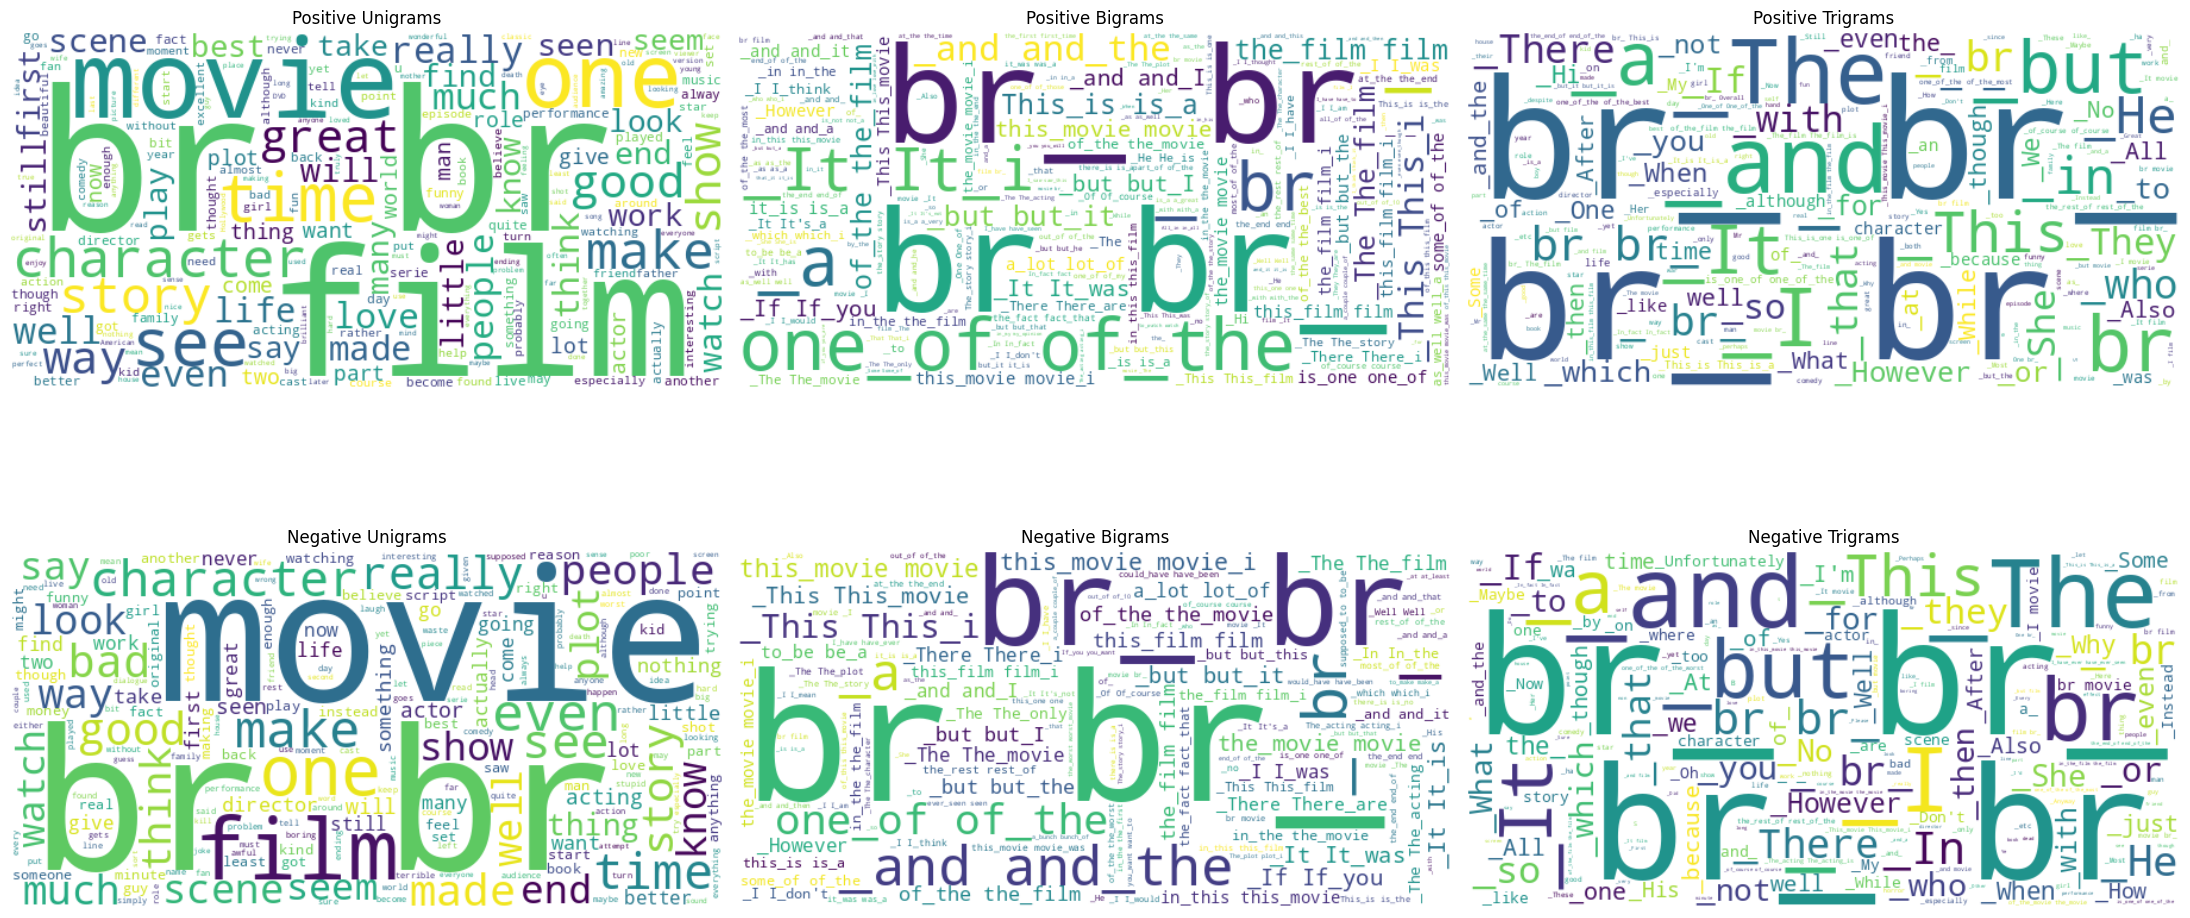

In [33]:
#Separate N-grams for positive and negative reviews

pos_reviews = train_df[train_df['label']==1]['review']
neg_reviews = train_df[train_df['label']==0]['review']

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

pos_unigrams = generate_all_ngrams(pos_reviews,1)
pos_bigrams = generate_all_ngrams(pos_reviews,2)
pos_trigrams = generate_all_ngrams(pos_reviews,3)

neg_unigrams = generate_all_ngrams(neg_reviews,1)
neg_bigrams = generate_all_ngrams(neg_reviews,2)
neg_trigrams = generate_all_ngrams(neg_reviews,3)

def ngrams_to_text(ngrams):
  return " ".join(["_".join(t) for t in ngrams])

pos_uni_text = ngrams_to_text(pos_unigrams)
pos_bi_text = ngrams_to_text(pos_bigrams)
pos_tri_text = ngrams_to_text(pos_trigrams)

neg_uni_text = ngrams_to_text(neg_unigrams)
neg_bi_text = ngrams_to_text(neg_bigrams)
neg_tri_text = ngrams_to_text(neg_trigrams)

def make_cloud(text):
  return WordCloud(width=600,height=300,background_color='white').generate(text)

fig,axes = plt.subplots(2,3,figsize=(22,12))

#Positive

axes[0,0].imshow(make_cloud(pos_uni_text),interpolation='bilinear')
axes[0,0].set_title("Positive Unigrams")
axes[0,0].axis("off")

axes[0,1].imshow(make_cloud(pos_bi_text),interpolation='bilinear')
axes[0,1].set_title("Positive Bigrams")
axes[0,1].axis("off")

axes[0,2].imshow(make_cloud(pos_tri_text),interpolation='bilinear')
axes[0,2].set_title("Positive Trigrams")
axes[0,2].axis("off")

#Negative

axes[1,0].imshow(make_cloud(neg_uni_text),interpolation='bilinear')
axes[1,0].set_title("Negative Unigrams")
axes[1,0].axis("off")

axes[1,1].imshow(make_cloud(neg_bi_text),interpolation='bilinear')
axes[1,1].set_title("Negative Bigrams")
axes[1,1].axis("off")

axes[1,2].imshow(make_cloud(neg_tri_text),interpolation='bilinear')
axes[1,2].set_title("Negative Trigrams")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()


Top positive TF-IDF words:
br:0.1057
movie:0.0511
film:0.0508
great:0.0258
good:0.0254
like:0.0250
story:0.0233
just:0.0211
time:0.0205
really:0.0195
Top negative TF-IDF words:
br:0.1200
movie:0.0666
film:0.0483
bad:0.0323
just:0.0319
like:0.0314
good:0.0251
really:0.0228
time:0.0215
don:0.0214


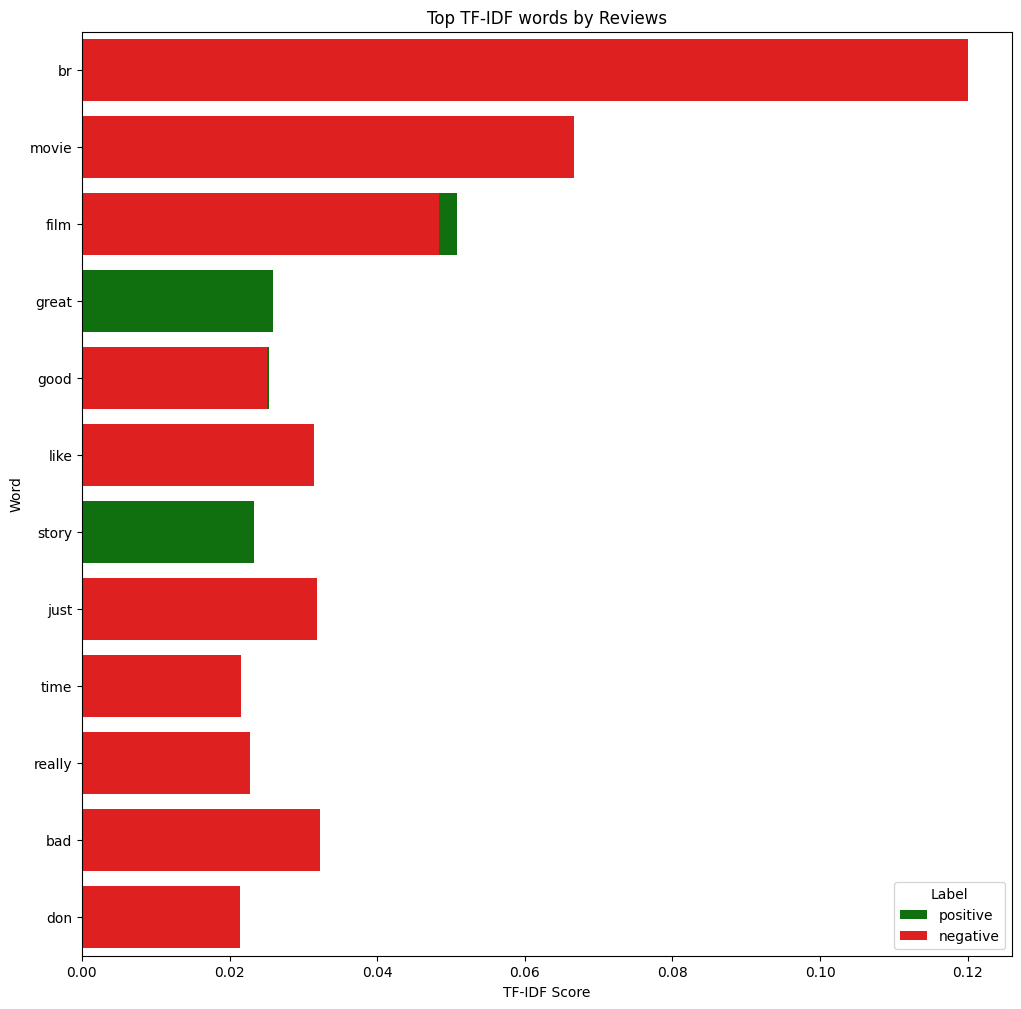

In [34]:
#TF-IDF Visualisation

tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,1),stop_words='english')

X = tfidf.fit_transform(train_df['review'])
feature_names = tfidf.get_feature_names_out()

pos_idx = train_df['label']==1
neg_idx = train_df['label']==0

X_pos = X[pos_idx.values]
X_neg = X[neg_idx.values]

pos_mean = np.asarray(X_pos.mean(axis=0)).ravel()
neg_mean = np.asarray(X_neg.mean(axis=0)).ravel()

top_n = 10

pos_top_idx = pos_mean.argsort()[-top_n:][::-1]
neg_top_idx = neg_mean.argsort()[-top_n:][::-1]

pos_top_words = [(feature_names[i],pos_mean[i]) for i in pos_top_idx]
neg_top_words = [(feature_names[i],neg_mean[i]) for i in neg_top_idx]

print("Top positive TF-IDF words:")
for word,score in pos_top_words:
  print(f"{word}:{score:.4f}")

print("Top negative TF-IDF words:")
for word,score in neg_top_words:
  print(f"{word}:{score:.4f}")

#Heatmap

df_heat = pd.DataFrame({"word":[w for w,s in pos_top_words] + [w for w,s in neg_top_words],
                        "score":[s for w,s in pos_top_words] + [s for w,s in neg_top_words],
                        "Label":["positive"]*top_n+["negative"]*top_n})

plt.figure(figsize=(12,12))
sns.barplot(data=df_heat,y="word",x="score",hue="Label",dodge=False,palette=["green","red"])
plt.title("Top TF-IDF words by Reviews")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()

**EDA SUMMARY**

Reference:
keras tutorial
ciattion
https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/

https://www.geeksforgeeks.org/deep-learning/keras-tuner-for-hyperparameter-optimization/

https://www.numberanalytics.com/blog/gru-text-classification

https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

https://keras.io/api/layers/convolution_layers/convolution1d/

**Data Preprocessing and Cleaning:**

In [109]:
#Function to strip HTML tags and punctuations

def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  removed_html = tf.strings.regex_replace(lowercase,'<br/>','')
  #removed_html = tf.strings.regex_replace('[^A-Za-z]','')
  #removed_html = tf.strings.regex_replace("\s+",'')
  return tf.strings.regex_replace(removed_html,f'[{re.escape(string.punctuation)}]','')

max_features = 10000 #Maximum Vocabulary size
sequence_length = 250  #Pad reviews

#Create Vectorizer
vectorize_layer = TextVectorization(standardize = custom_standardization,
                                    max_tokens=max_features,
                                    output_mode='int',
                                    output_sequence_length=sequence_length)

#Adapt on Training text only
train_text = raw_train_ds.map(lambda x,y:x)
vectorize_layer.adapt(train_text)

#Apply vectorization to all datasets
def vectorize_text(text,label):
  text = tf.expand_dims(text,-1)
  return vectorize_layer(text),label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

#Optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model Building and Interpretation:

# BaseLine Model:

In [36]:
#Baseline Model:

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

model = keras.Sequential([layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.GlobalAveragePooling1D(), #average all the wordvectorsin teh sequence
                          layers.Dense(16,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

#Compile the model

model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history = model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss,val_acc = model.evaluate(val_ds)
print('Validation Accuracy',val_acc)
print('Validation Loss',val_loss)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1771737418.337773     224 service.cc:152] XLA service 0x7ec928003e50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771737418.337815     224 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771737418.596869     224 cuda_dnn.cc:529] Loaded cuDNN version 91002


 52/625 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4959 - loss: 0.6935

I0000 00:00:1771737419.224936     224 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6027 - loss: 0.6502 - val_accuracy: 0.8408 - val_loss: 0.3891
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8489 - loss: 0.3561 - val_accuracy: 0.8580 - val_loss: 0.3256
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8910 - loss: 0.2725 - val_accuracy: 0.8596 - val_loss: 0.3186
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9087 - loss: 0.2316 - val_accuracy: 0.8576 - val_loss: 0.3263
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9210 - loss: 0.2031 - val_accuracy: 0.8558 - val_loss: 0.3422
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8540 - loss: 0.3427
Validation Accuracy 0.8557999730110168
Validation Loss 0.34216535091400146


**Evaluation Metrics (Baseline Model):**

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8540 - loss: 0.3427
Validation Accuracy 0.8557999730110168
Validation Loss 0.34216535091400146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━

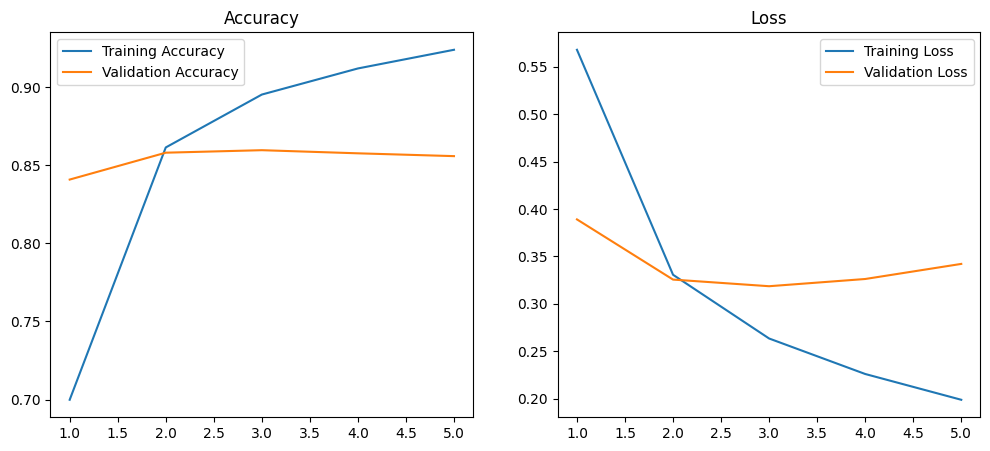

In [37]:
#Baseline Evaluation Metrics
val_loss_baseline,val_acc_baseline = model.evaluate(val_ds)
print('Validation Accuracy',val_acc_baseline)
print('Validation Loss',val_loss_baseline)

y_true_baseline=[]
y_pred_baseline=[]

for text_batch,label_batch in val_ds:
  preds = model.predict(text_batch)
  y_true_baseline.extend(label_batch.numpy())
  y_pred_baseline.extend((preds>0.5).astype('int32'))

cm_baseline = confusion_matrix(y_true_baseline,y_pred_baseline)
print(cm_baseline)

print(classification_report(y_true_baseline,y_pred_baseline))

history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()


**Baseline Summary:**

The accuracy of the baseline model is 0.85 which is good for a baseline model.This can be used as a benchmark to compare with the other models.

Model is good at identifying negative reviews than positive reviews.(TN - )Likely to Miss positive reviews(Higher FN)

This is confirmed in the classification Report summary.Negative reviews have higher recall and F1 score than the positive reviews (0 - 0.86, 1 - 0.84)

**Acccuracy Plot:**

Training accuracy climbs steadily after 0.85 and it reaches 0.925.Validation accuracy reaches around 0.85.Looks like overfitting which is natural for baseline model.

**Loss Plot:**

Training Loss is very high initially and then decreases.
Validation loss remains around 0.3 which confirms the overfitting pattern.

Baseline models overfits which is normal and this can be used as a base for other models.

# BiLSTM:

BiLSTM captures the information both forward and backward thereby capturing more contextual information.It is good at capturing negation,contrast etc.(like 'Not Good').

In [38]:
#Used the same parameters I have used in baseline for comparison

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.Bidirectional(layers.LSTM(64,return_sequences=False)) ,
                          layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history_bilstm = bilstm_model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss_bilstm,val_acc_bilstm = bilstm_model.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm)
print('Val Loss',val_loss_bilstm)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6602 - loss: 0.5961 - val_accuracy: 0.8416 - val_loss: 0.3771
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8717 - loss: 0.3202 - val_accuracy: 0.7892 - val_loss: 0.4992
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8875 - loss: 0.2901 - val_accuracy: 0.8594 - val_loss: 0.3329
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9303 - loss: 0.1958 - val_accuracy: 0.8608 - val_loss: 0.3613
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9381 - loss: 0.1703 - val_accuracy: 0.8232 - val_loss: 0.4339
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8285 - loss: 0.4253
Val Accuracy 0.823199987411499
Val Loss 0.4338777959346771


In [41]:
#Used the same parameters I have used in baseline for comparison
#Due to overfitting, have added regularization

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model_1 = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.3),

    layers.Bidirectional(layers.LSTM(32,dropout=0.3)) ,
    layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model_1.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
#Train Model

history_bilstm_1 = bilstm_model_1.fit(train_ds,validation_data=val_ds,epochs=2,callbacks=[early_stop])

#Evaluate
val_loss_bilstm_1,val_acc_bilstm_1 = bilstm_model_1.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm_1)
print('Val Loss',val_loss_bilstm_1)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6359 - loss: 0.6085 - val_accuracy: 0.8536 - val_loss: 0.3478
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8622 - loss: 0.3506 - val_accuracy: 0.8656 - val_loss: 0.3302
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8599 - loss: 0.3367
Val Accuracy 0.8655999898910522
Val Loss 0.33015885949134827


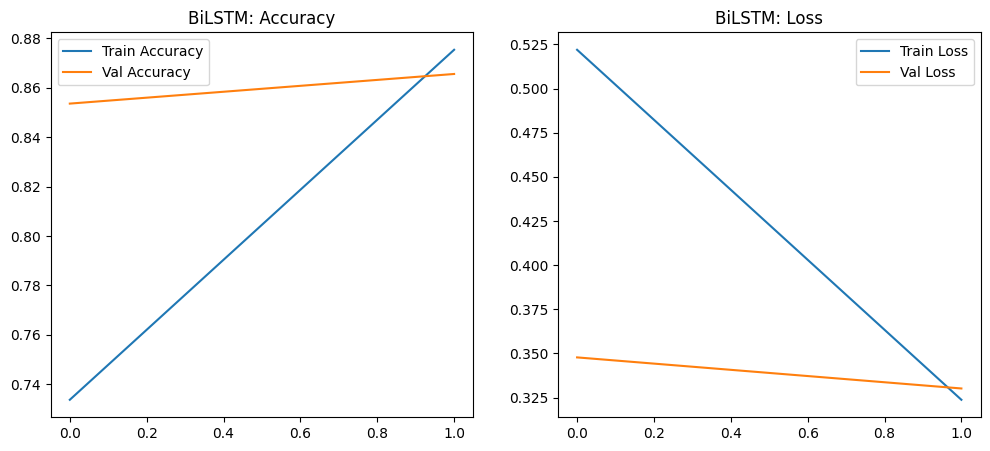

In [42]:
#Training Curve:

#BiLSTM Training Curve

acc_bilstm = history_bilstm_1.history['accuracy']
val_acc_bilstm = history_bilstm_1.history['val_accuracy']
loss_bilstm = history_bilstm_1.history['accuracy']
val_loss_bilstm = history_bilstm_1.history['val_loss']

epochs_bilstm = range(1,len(acc_bilstm)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_bilstm_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm_1.history['val_accuracy'], label='Val Accuracy')
plt.title('BiLSTM: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_bilstm_1.history['loss'], label='Train Loss')
plt.plot(history_bilstm_1.history['val_loss'], label='Val Loss')
plt.title('BiLSTM: Loss')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      2462
           1       0.90      0.83      0.86      2538

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



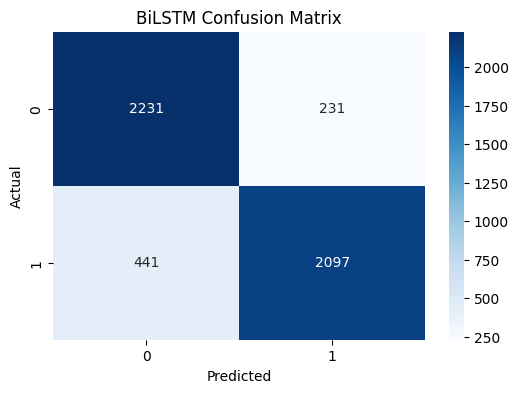

In [43]:
#Evaluation Metric:

#Classification Report
y_true_bilstm = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_bilstm = bilstm_model_1.predict(val_ds)
y_pred_bilstm = (y_pred_probs_bilstm > 0.5).astype("int32")

print(classification_report(y_true_bilstm, y_pred_bilstm))

#Confusion Matrix

cm_bilstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")
plt.show()

In [60]:
#Hyperparameter Tuning BiLSTM

def build_model_bilstm(bilstm):
    # 1. Tune the number of units in the LSTM layer
    # Choose an optimal value between 32-128
    bilstm_units = bilstm.Int('units', min_value=32, max_value=64, step=32)

    # 2. Tune the dropout rate
    bilstm_dropout = bilstm.Float('dropout', min_value=0.2, max_value=0.3, step=0.1)

    # 3. Tune the learning rate
    bilstm_learning_rate = bilstm.Choice('learning_rate', values=[1e-3])

    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
        layers.SpatialDropout1D(0.3),

        # Removed recurrent_dropout for CuDNN speed
        layers.Bidirectional(layers.LSTM(units=bilstm_units, dropout=bilstm_dropout)),

        layers.Dense(bilstm_units, activation='relu'),
        layers.Dropout(bilstm_dropout),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=bilstm_learning_rate),
        loss='binary_crossentropy',
            metrics=['accuracy']
        )
    return model
    
    # Initialize the Tuner (Hyperband is efficient)
tuner_bilstm = kt.Hyperband(
        build_model_bilstm,
        objective='val_accuracy',
        max_epochs=2,
        factor=3,
        directory='my_dir',
        project_name='imdb_bilstm_tuning'
    )
    
    # Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    
    # Start searching
tuner_bilstm.search(train_ds, validation_data=val_ds, epochs=2, callbacks=[early_stop],verbose=2)
    
    # Get the best model
best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]



Trial 2 Complete [00h 00m 38s]
val_accuracy: 0.8605999946594238

Best val_accuracy So Far: 0.8704000115394592
Total elapsed time: 00h 01m 12s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [61]:

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]

final_bilstm_model = tuner_bilstm.hypermodel.build(best_hps_bilstm)

history_bilstm_tuned = final_bilstm_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=5, 
    callbacks=[early_stop],
    verbose=2
)



Epoch 1/5
625/625 - 18s - 28ms/step - accuracy: 0.7081 - loss: 0.5564 - val_accuracy: 0.8244 - val_loss: 0.4252
Epoch 2/5
625/625 - 15s - 23ms/step - accuracy: 0.8457 - loss: 0.3819 - val_accuracy: 0.8546 - val_loss: 0.3522
Epoch 3/5
625/625 - 15s - 23ms/step - accuracy: 0.8921 - loss: 0.2790 - val_accuracy: 0.8344 - val_loss: 0.4360
Epoch 4/5
625/625 - 15s - 23ms/step - accuracy: 0.9068 - loss: 0.2495 - val_accuracy: 0.8392 - val_loss: 0.3753


In [64]:
#Evaluation Metric for the best model


best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]

y_true_bilstm_tuned = np.concatenate([y for x,y in test_ds],axis=0)
y_pred_probs_bilstm_tuned = best_model_bilstm.predict(test_ds)
y_pred_bilstm_tuned = (y_pred_probs_bilstm_tuned > 0.5).astype("int32")

print("=== Final Evaluation Report: BiLSTM Model===")
print(classification_report(y_true_bilstm_tuned,y_pred_bilstm_tuned,target_names=['Negative','Positive']))

#Best Hyperparameters

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
=== Final Evaluation Report: BiLSTM Model===
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86     12500
    Positive       0.86      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000




 === Optimized Best Hyperparameters ===
LSTM Units: 32
Dropout Rate: 0.2
Learning Rate: 0.001


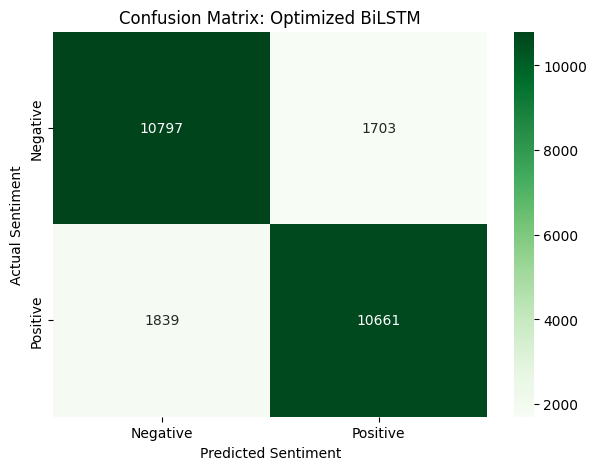

In [65]:
print("\n === Optimized Best Hyperparameters ===")
print(f"LSTM Units: {best_hps_bilstm.get('units')}")
print(f"Dropout Rate: {best_hps_bilstm.get('dropout')}")
print(f"Learning Rate: {best_hps_bilstm.get('learning_rate')}")

#Confusion Matrix

cm_bilstm_tuned = confusion_matrix(y_true_bilstm_tuned, y_pred_bilstm_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_bilstm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Optimized BiLSTM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# 1D CNN:
While BiLSTM reads word by word in both the directions,1D CNN uses filers to slide across the sentence to pick the patterns.

**Architecture:**

*   Embedding Layer - Turns words into vectors
*   Convolution Layer - Learns local patters(n-grams)
*   Global MaxPooling - Pickts the most important feature from the window
*   Dense Layer - To learn complex patterns
*   Dropout - Reduce overfitting
*   Dense Layer - Makes the final prediction



In [67]:
#1DCNN

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#1DCNN model
cnn_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.2),
    layers.Conv1D(filters=64,kernel_size=5,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)) ,
    layers.GlobalMaxPooling1D(),
    layers.Dense(64,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

cnn_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
early_stop_cnn = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2)
history_cnn_standard = cnn_model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop_cnn])
cnn_model.summary()

#Evaluate
val_loss_cnn,val_acc_cnn = cnn_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_cnn)
print('CNN Val Loss',val_loss_cnn)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6029 - loss: 0.6656 - val_accuracy: 0.8434 - val_loss: 0.3853
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8566 - loss: 0.3688 - val_accuracy: 0.8654 - val_loss: 0.3477
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9217 - loss: 0.2421 - val_accuracy: 0.8646 - val_loss: 0.3825
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9594 - loss: 0.1552 - val_accuracy: 0.8590 - val_loss: 0.4594


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 246, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,309 (14.93 MB)

 Trainable params: 1,304,769 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,540 (9.95 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8668 - loss: 0.4388
CNN Val Accuracy 0.859000027179718
CNN Val Loss 0.45939967036247253


The 1D CNN model show signs of overfitting .The training loss starts at 0.65 and decreases to 0.16 while the validation loss increases from 0.42 to 0.40.This indicates that the model begins to capture noise specific to the training set rather than broad sentiment patterns.

Early stopping is used to stop at the moment the validation loss starts improving.

Next,I am going to use keras Tuner find the best set of hyperparameters of 1D CNN model.



*   Spatial Dropout - 0.1,0.2,0.3,0.4

*   Filters = 32,64,96,128
*   Kernel_size = 3,5,7


*   List item



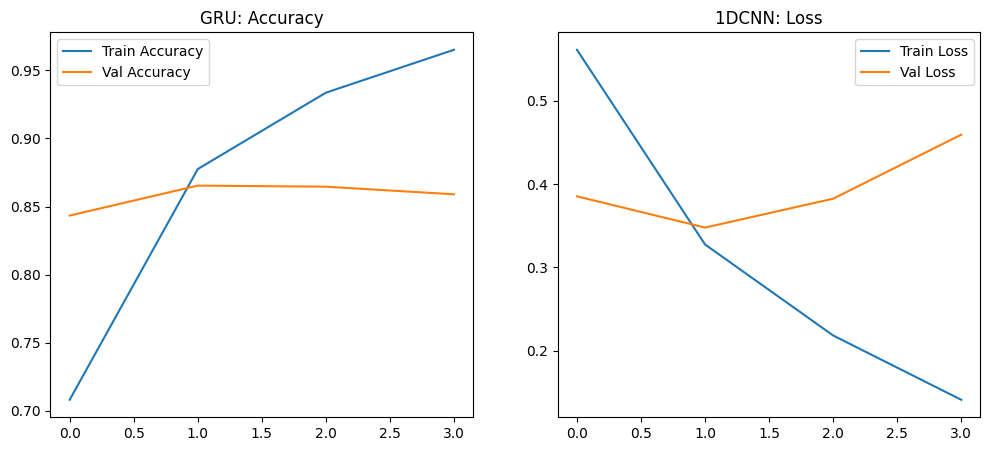

In [68]:
#1DCNN Training Curve

acc_cnn = history_cnn_standard.history['accuracy']
val_acc_cnn = history_cnn_standard.history['val_accuracy']
loss_cnn = history_cnn_standard.history['accuracy']
val_loss_cnn = history_cnn_standard.history['val_loss']

epochs = range(1,len(acc_cnn)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn_standard.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_standard.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn_standard.history['loss'], label='Train Loss')
plt.plot(history_cnn_standard.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      2462
           1       0.83      0.91      0.87      2538

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



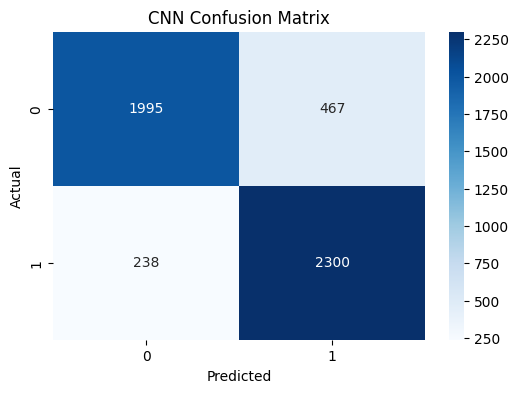

In [69]:
#Classification Report
y_true_cnn = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn = cnn_model.predict(val_ds)
y_pred_cnn = (y_pred_probs_cnn > 0.5).astype("int32")

print(classification_report(y_true_cnn, y_pred_cnn))

#Confusion Matrix

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## **Analysis:**

**Accuracy Graph**

*   Training accuracy starts very low and becomes closer to 1 by last epochs.
*   Validation accuracy begina at 85% , briefly increases a bit to 87% and then almost remains the same till the last epochs.
*   This means that the model is memorizing and it will work only on the training data and not on the unseen validation data.

**Loss Graph:**

*   Training Loss decreases rapidly from 0.5 to near ~0 , which shows almost perfect training accuracy.
*   Validation loss, on the other hand, starts low and then increases across epochs, confirming that additional training will increase it further.
*   This indicates a sign of overfitting.

Keras Tuner gave the best possible hyperparamater combination based on the highest Validation accuracy.But from the above 2 plots, we found that there is a classic sign of overfitting.So, picking the epoch with the lowest validation loss which tells when to stop training for a given hyperparameter set.






In [70]:
#In the same hyperparameter tuning I used earlier, am going to change the objective to val_loss

def build_cnn_hypermodel(cnn):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=cnn.Float('spatial_dropout', min_value=0.1, max_value=0.2, step=0.1)
    ))

    #Conv1D Filters and Kernel Size
    model.add(layers.Conv1D(
        filters=cnn.Int('filters', min_value=32, max_value=64, step=32),
        kernel_size=cnn.Choice('kernel_size', values=[3, 5]),
        activation='relu'
    ))

    model.add(layers.GlobalMaxPooling1D())

    #Dense Layer Units
    model.add(layers.Dense(
        units=cnn.Int('dense_units', min_value=32, max_value=64, step=32),
        activation='relu'
    ))

    model.add(layers.Dropout(cnn.Float('dropout', 0.2, 0.3, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = cnn.Choice('learning_rate', values=[1e-2])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_cnn = kt.Hyperband(
    build_cnn_hypermodel,
    objective='val_loss',
    max_epochs=2,
    factor=3,
    directory='cnn_tuning_dir',
    project_name='imdb_cnn_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

tuner_cnn.search(train_ds, validation_data=val_ds, epochs=2, callbacks=[stop_early],verbose=2)

# Get the best hyperparameters
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Filters: {best_hps_cnn.get('filters')}")
print(f"Optimal Kernel Size: {best_hps_cnn.get('kernel_size')}")
print(f"Optimal Spatial Dropout: {best_hps_cnn.get('spatial_dropout')}")

# Build the model with the best hyperparameters and train it
best_cnn_model = tuner_cnn.hypermodel.build(best_hps_cnn)
history_cnn = best_cnn_model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=[stop_early])


Reloading Tuner from cnn_tuning_dir/imdb_cnn_search/tuner0.json
Optimal Filters: 32
Optimal Kernel Size: 3
Optimal Spatial Dropout: 0.1
Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7213 - loss: 0.5229 - val_accuracy: 0.8436 - val_loss: 0.3549
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8695 - loss: 0.3237 - val_accuracy: 0.8534 - val_loss: 0.3918


In [72]:
#Get best hyperparameters from tuner
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

#uild and train a model with hyperparameters
best_model_cnn = tuner_cnn.hypermodel.build(best_hps_cnn)

history_cnn = best_model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,              # or more, with EarlyStopping if you like
    callbacks=[stop_early]
)

#val_loss and corresponding val_accuracy
val_loss_history_cnn = history_cnn.history["val_loss"]
val_acc_history_cnn  = history_cnn.history["val_accuracy"]

best_epoch_cnn = int(np.argmin(val_loss_history_cnn))  # index of lowest val_loss
best_val_loss_cnn = float(val_loss_history_cnn[best_epoch_cnn])
best_val_acc_cnn  = float(val_acc_history_cnn[best_epoch_cnn])

print("Best epoch:", best_epoch_cnn + 1)
print("Best val_loss:", best_val_loss_cnn)
print("Best val_accuracy:", best_val_acc_cnn)


cnn_result = {
    "model_name": "1D_CNN_tuned",
    "best_epoch": best_epoch_cnn + 1,
    "best_val_loss": best_val_loss_cnn,
    "best_val_accuracy": best_val_acc_cnn,
    "filters": best_hps_cnn.get("filters"),
    "kernel_size": best_hps_cnn.get("kernel_size"),
    "spatial_dropout": best_hps_cnn.get("spatial_dropout"),
    "dense_units": best_hps_cnn.get("dense_units"),
    "dropout": best_hps_cnn.get("dropout"),
    "learning_rate": best_hps_cnn.get("learning_rate"),
}

print(cnn_result)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7214 - loss: 0.5253 - val_accuracy: 0.8546 - val_loss: 0.3625
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8637 - loss: 0.3279 - val_accuracy: 0.8496 - val_loss: 0.3502
Best epoch: 2
Best val_loss: 0.350157767534256
Best val_accuracy: 0.8496000170707703
{'model_name': '1D_CNN_tuned', 'best_epoch': 2, 'best_val_loss': 0.350157767534256, 'best_val_accuracy': 0.8496000170707703, 'filters': 32, 'kernel_size': 3, 'spatial_dropout': 0.1, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.01}


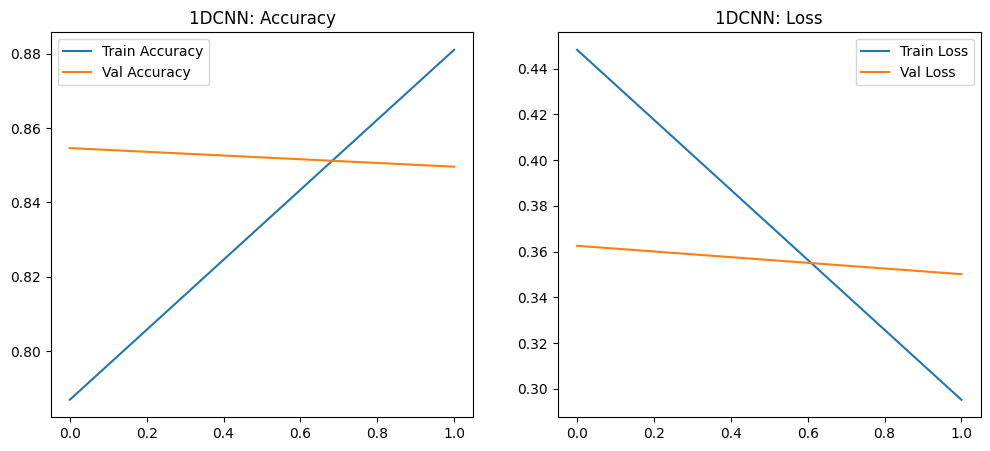

In [73]:
#1DCNN Hyperparameter Tuned Training Curve

acc_cnn_tuned = history_cnn.history['accuracy']
val_acc_cnn_tuned = history_cnn.history['val_accuracy']
loss_gru = history_cnn.history['accuracy']
val_loss_gru = history_cnn.history['val_loss']

epochs = range(1,len(acc_cnn_tuned)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1DCNN: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


# Evaluation Metrics:

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      2462
           1       0.88      0.81      0.85      2538

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



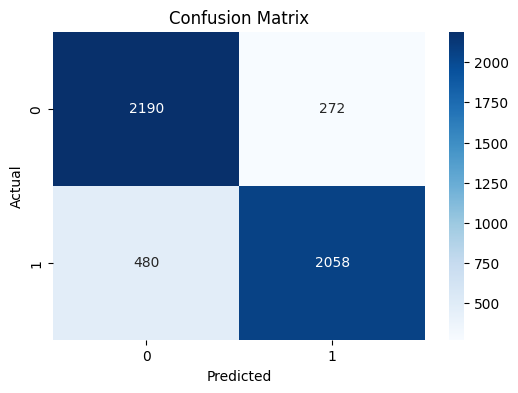

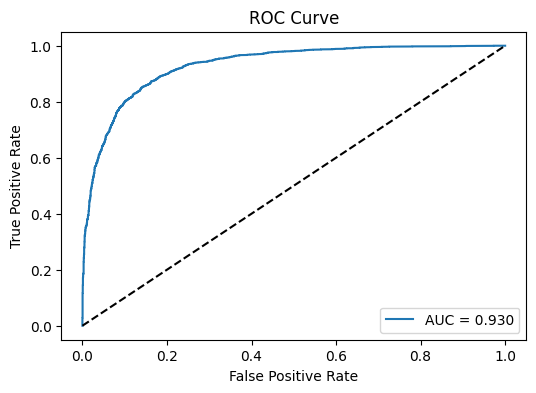

In [74]:
y_true_cnn_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn_tuned = best_model_cnn.predict(val_ds)
y_pred_cnn_tuned = (y_pred_probs_cnn_tuned > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true_cnn_tuned, y_pred_cnn_tuned))

# Confusion Matrix
cm_cnn_tuned = confusion_matrix(y_true_cnn_tuned, y_pred_cnn_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#ROC AUC Curve

fpr_cnn_tuned, tpr_cnn_tuned, thresholds_cnn_tuned = roc_curve(y_true_cnn_tuned, y_pred_probs_cnn_tuned)
roc_auc_cnn_tuned = auc(fpr_cnn_tuned, tpr_cnn_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr_cnn_tuned, tpr_cnn_tuned, label=f"AUC = {roc_auc_cnn_tuned:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

1D CNN Summary:



*   Based on the chosen architecture, I first built a 1D‑CNN model and evaluated its performance using validation accuracy. The results indicated clear signs of overfitting.

*   Next, I used Keras Tuner to search for optimal hyperparameters using validation accuracy as the objective.
*   Although the tuner identified a configuration with improved validation accuracy, the training curves still showed overfitting.


*   To address this, I ran Keras Tuner again—this time optimizing for validation loss instead of accuracy. This approach produced a more stable model with better generalization.

*   Using the best hyperparameters identified through the val_loss‑based search, the following section summarizes the optimal hyperparameter combination and provides a brief performance report.
*   Best epoch: 8
Best val_loss: 0.30746176838874817
Best val_accuracy: 0.8744000196456909

{'model_name': '1D_CNN_tuned', 'best_epoch': 8, 'best_val_loss': 0.30746176838874817, 'best_val_accuracy': 0.8744000196456909, 'filters': 96, 'kernel_size': 7, 'spatial_dropout': 0.30000000000000004, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.0001}










# Gated Recurrent Networks: (GRU)

In [78]:
vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#GRU model
gru_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),

    GRU(64,dropout=0.2),
    Dense(1,activation='sigmoid')
])

gru_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
history_gru_standard = gru_model.fit(train_ds,validation_data=val_ds,epochs=2,batch_size=64,callbacks=[stop_early],verbose=2)
gru_model.summary()

#Evaluate
val_loss_gru,val_acc_gru = gru_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_gru)
print('CNN Val Loss',val_loss_gru)

Epoch 1/2
625/625 - 11s - 17ms/step - accuracy: 0.5106 - loss: 0.6933 - val_accuracy: 0.5136 - val_loss: 0.6920
Epoch 2/2
625/625 - 9s - 14ms/step - accuracy: 0.5589 - loss: 0.6717 - val_accuracy: 0.5266 - val_loss: 0.7034


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,915,077 (14.93 MB)

 Trainable params: 1,305,025 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,610,052 (9.96 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5244 - loss: 0.6905
CNN Val Accuracy 0.5135999917984009
CNN Val Loss 0.691989004611969


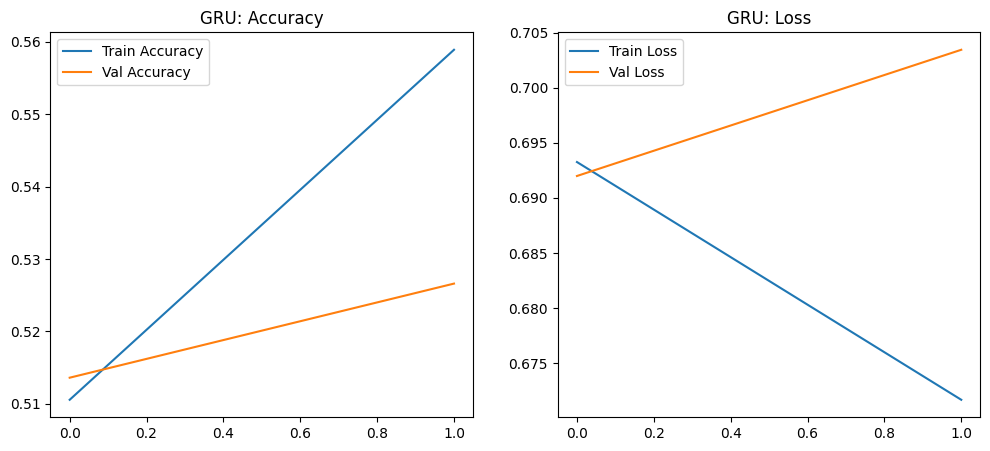

In [79]:
#GRU Training Curve

acc_gru = history_gru_standard.history['accuracy']
val_acc_gru = history_gru_standard.history['val_accuracy']
loss_gru = history_gru_standard.history['accuracy']
val_loss_gru = history_gru_standard.history['val_loss']

epochs = range(1,len(acc_gru)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_gru_standard.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru_standard.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_gru_standard.history['loss'], label='Train Loss')
plt.plot(history_gru_standard.history['val_loss'], label='Val Loss')
plt.title('GRU: Loss')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.57      0.05      0.09      2462
           1       0.51      0.96      0.67      2538

    accuracy                           0.51      5000
   macro avg       0.54      0.51      0.38      5000
weighted avg       0.54      0.51      0.38      5000



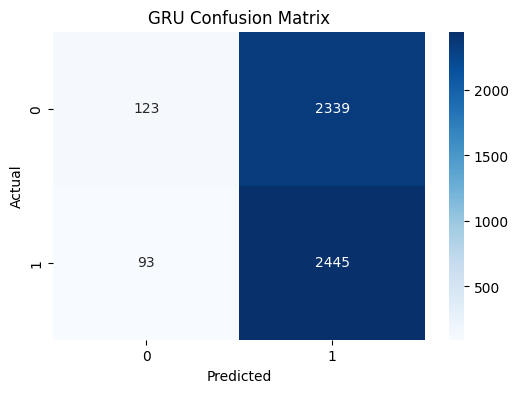

In [80]:
#Classification Report
y_true_gru = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru = gru_model.predict(val_ds)
y_pred_gru = (y_pred_probs_gru > 0.5).astype("int32")

print(classification_report(y_true_gru, y_pred_gru))

#Confusion Matrix

cm_gru = confusion_matrix(y_true_gru, y_pred_gru)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

Next, I performed hyper parameter tuning on the GRU model using keras Tuner.

*   rate = [0.1,0.2,0.3,0.4]
*   units = [32,64,128]
*   dropout = [0.2,0.3,0.5]
*   lr = [1e-3,5e-4,1e-4]

The Tuner will test multiple combinations and the best model will be selected based on the minimum validation loss.Early stoppping is used to restore best weights.



In [83]:
#Hypertuned GRU
#rate = [0.1,0.2,0.3,0.4]
#units = [32,64,128]
#dropout = [0.2,0.3,0.5]
#lr = [1e-3,5e-4,1e-4]

def build_gru_hypermodel(gru):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=gru.Float('spatial_dropout', min_value=0.1, max_value=0.2, step=0.1)
    ))

    units = gru.Choice("units",[32])
    dropout = gru.Choice("dropout",[0.2,0.3])

    model.add(layers.GRU(
        units,
        dropout=dropout
    ))

    #Dense Layer Units
    model.add(layers.Dense(
        units=gru.Int('dense_units', min_value=32, max_value=64, step=32),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = gru.Choice('learning_rate', values=[1e-3])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_gru = kt.RandomSearch(
    build_gru_hypermodel,
    objective='val_loss',
    max_trials=2,
    directory='gru_tuning',
    project_name='imdb_gru_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2,restore_best_weights=True)

tuner_gru.search(train_ds, validation_data=val_ds, epochs=2, callbacks=[stop_early])

# Get the best hyperparameters
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
best_hps_gru.values

print("Best Hyperparameters:")
print(f"Spatial Dropout: {best_hps_gru.get('spatial_dropout')}")
print(f"GRU Units: {best_hps_gru.get('units')}")
print(f"Dropout: {best_hps_gru.get('dropout')}")
print(f"Dense Units: {best_hps_gru.get('dense_units')}")
print(f"Learning Rate: {best_hps_gru.get('learning_rate')}")

# Build the model with the best hyperparameters and train it
best_gru_model = tuner_gru.hypermodel.build(best_hps_gru)
history_gru = best_gru_model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=[stop_early],verbose=2)

val_loss_history_gru = history_gru.history["val_loss"]
best_epoch_gru = int(np.argmin(val_loss_history_gru))+ 1

gru_tuned_result = {
    "model_name": "GRU_tuned",
    "best_epoch": best_epoch_gru,
    "best_val_loss": float(min(val_loss_history_gru)),
    "best_val_accuracy": float(max(history_gru.history["val_accuracy"])),
    "units": best_hps_gru.get("units"),
    "dropout": best_hps_gru.get("dropout"),
    "dense_units": best_hps_gru.get("dense_units"),
    "learning_rate": best_hps_gru.get("learning_rate"),
}

print(gru_tuned_result)


Trial 2 Complete [00h 00m 22s]
val_loss: 0.693169116973877

Best val_loss So Far: 0.6915475130081177
Total elapsed time: 00h 00m 44s
Best Hyperparameters:
Spatial Dropout: 0.2
GRU Units: 32
Dropout: 0.3
Dense Units: 64
Learning Rate: 0.001
Epoch 1/2
625/625 - 10s - 16ms/step - accuracy: 0.5092 - loss: 0.6929 - val_accuracy: 0.5124 - val_loss: 0.6919
Epoch 2/2
625/625 - 8s - 13ms/step - accuracy: 0.5415 - loss: 0.6803 - val_accuracy: 0.5020 - val_loss: 0.6954
{'model_name': 'GRU_tuned', 'best_epoch': 1, 'best_val_loss': 0.6918870806694031, 'best_val_accuracy': 0.5123999714851379, 'units': 32, 'dropout': 0.3, 'dense_units': 64, 'learning_rate': 0.001}


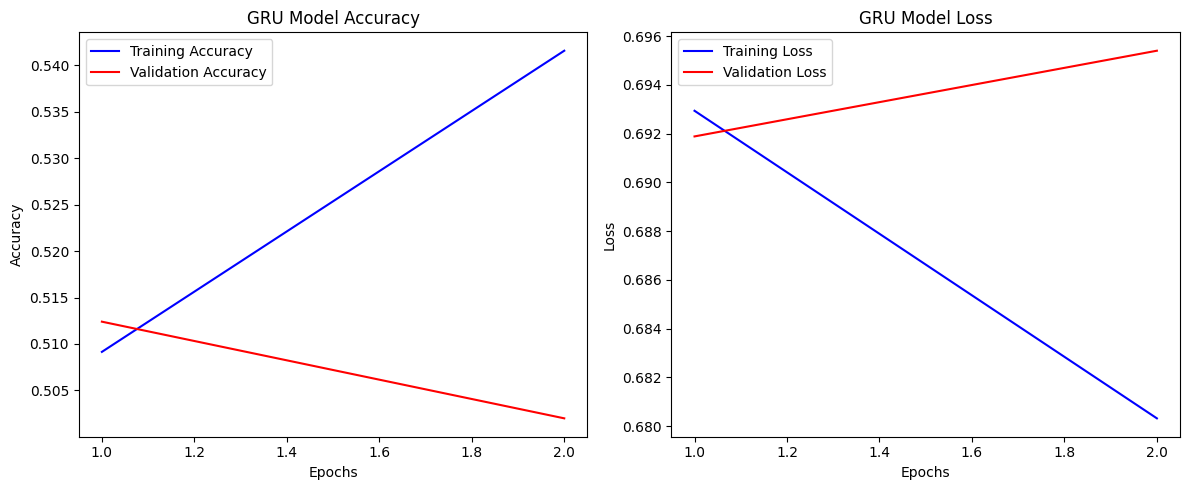

In [86]:
#Loss and Accuracy Plot

acc_gru_tuned = history_gru.history['accuracy']
val_acc_gru_tuned = history_gru.history['val_accuracy']
loss_gru_tuned = history_gru.history['loss']
val_loss_gru_tuned = history_gru.history['val_loss']

epochs = range(1, len(acc_gru_tuned) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc_gru_tuned, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc_gru_tuned, 'r-', label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss_gru_tuned, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_gru_tuned, 'r-', label='Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.59      0.03      0.06      2462
           1       0.51      0.98      0.67      2538

    accuracy                           0.51      5000
   macro avg       0.55      0.51      0.36      5000
weighted avg       0.55      0.51      0.37      5000



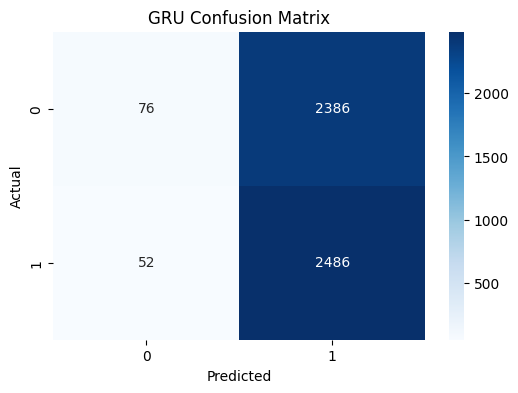

In [89]:
#Classification Report
y_true_gru_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru_tuned = best_gru_model.predict(val_ds)
y_pred_gru_tuned = (y_pred_probs_gru_tuned > 0.5).astype("int32")

print(classification_report(y_true_gru_tuned, y_pred_gru_tuned))

#Confusion Matrix

cm_gru_tuned = confusion_matrix(y_true_gru_tuned, y_pred_gru_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()


In [92]:
import json
import pickle
import os
import numpy as np
from sklearn.metrics import classification_report

def save_full_model_assets(model, history, name, val_ds):
    # Create directory
    folder = 'imdb_models'
    if not os.path.exists(folder): os.makedirs(folder)
    
    # 1. Save Model Architecture Summary as string
    summary_list = []
    model.summary(print_fn=lambda x: summary_list.append(x))
    with open(f'{folder}/{name}_summary.txt', 'w') as f:
        f.write("\n".join(summary_list))
    
    # 2. Save Training History (Acc, Loss for both Train & Val)
    with open(f'{folder}/{name}_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
        
    # 3. Generate and Save Detailed Metrics (Precision, Recall, F1)
    # Get true labels and predictions
    y_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_pred_probs = model.predict(val_ds)
    y_pred = (y_pred_probs > 0.5).astype("int32")
    
    # Get classification report as a dictionary
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # 4. Save a consolidated JSON for the comparison table
    metrics = {
        "model_name": name,
        "val_accuracy": report['accuracy'],
        "val_loss": history.history['val_loss'][-1],
        "precision": report['weighted avg']['precision'],
        "recall": report['weighted avg']['recall'],
        "f1_score": report['weighted avg']['f1-score']
    }
    
    with open(f'{folder}/{name}_metrics.json', 'w') as f:
        json.dump(metrics, f)
        
    # 5. Save the .keras model file
    model.save(f'{folder}/{name}_model.keras')
    print(f"All assets for {name} saved to {folder}/")

In [93]:
save_full_model_assets(cnn_model, history_cnn_standard, "CNN_standard", val_ds)
save_full_model_assets(best_model_cnn, history_cnn, "CNN_tuned", val_ds)
save_full_model_assets(gru_model, history_gru_standard, "GRU_Standard", val_ds)
save_full_model_assets(best_gru_model, history_gru, "GRU_tuned", val_ds)
save_full_model_assets(bilstm_model_1, history_bilstm_1, "BiLSTM Standard",val_ds)
save_full_model_assets(final_bilstm_model, history_bilstm_tuned, "BiLSTM_tuned", val_ds)
save_full_model_assets(model, history, "Baseline", val_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
All assets for CNN_standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
All assets for CNN_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
All assets for GRU_Standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
All assets for GRU_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
All assets for BiLSTM Standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
All assets for BiLSTM_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
All assets for Baseline saved to imdb_models/


In [115]:
#CHECK

def get_model_stats(model, model_name, history_obj, dataset):
    all_labels = []
    all_preds = []
    
    # SINGLE PASS: Get labels and predictions at the same time
    for texts, labels in dataset:
        preds = model.predict(texts, verbose=0)
        all_labels.extend(labels.numpy())
        all_preds.extend((preds > 0.5).astype(int).flatten())
    
    # Now calculate metrics from the paired lists
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return {
        "Model": model_name,
        "Train_Acc": history_obj.history['accuracy'][-1],
        "Train_Loss": history_obj.history['loss'][-1],
        "Val_Acc": history_obj.history['val_accuracy'][-1],
        "Val_Loss": history_obj.history['val_loss'][-1],
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [116]:
#CHECK

results = []
raw_val_ds = tf.keras.utils.text_dataset_from_directory('aclImdb/train',validation_split=0.2,subset='validation',batch_size=32,shuffle=False,seed=42)
val_ds = raw_val_ds.map(lambda x,y: (vectorize_layer(x),y))
# Example for BiLSTM Tuned
results.append(get_model_stats(model, "Baseline", history, val_ds))
results.append(get_model_stats(bilstm_model_1, "BiLSTM Standard", history_bilstm_1, val_ds))
results.append(get_model_stats(final_bilstm_model, "BiLSTM Tuned", history_bilstm_tuned, val_ds))
results.append(get_model_stats(cnn_model, "CNN Standard", history_cnn_standard, val_ds))
results.append(get_model_stats(best_model_cnn, "CNN Tuned", history_cnn, val_ds))
results.append(get_model_stats(gru_model, "GRU Standard", history_gru_standard, val_ds))
results.append(get_model_stats(best_gru_model, "GRU Tuned", history_gru, val_ds))

# Example for Baseline
# results.append(get_model_stats(baseline_model, "Baseline", history_baseline, raw_test_ds))

# 3. Display as a Table
df_performance = pd.DataFrame(results)
#print(df_performance.to_string(index=False))

styled_df = df_performance.style.highlight_max(subset=['Val_Acc', 'F1'], color='lightgreen') \
                                .highlight_min(subset=['Val_Loss'], color='lightgreen') \
                                .format(precision=4)
display(styled_df)

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


,Model,Train_Acc,Train_Loss,Val_Acc,Val_Loss,Precision,Recall,F1
0,Baseline,0.9238,0.1989,0.8558,0.3422,1.0000,0.8694,0.9301
1,BiLSTM Standard,0.8754,0.3238,0.8656,0.3302,1.0000,0.8804,0.9364
2,BiLSTM Tuned,0.9068,0.2495,0.8392,0.3753,1.0000,0.9132,0.9546
3,CNN Standard,0.9682,0.1361,0.8668,0.4279,1.0000,0.9746,0.9871
4,CNN Tuned,0.8810,0.2953,0.8496,0.3502,1.0000,0.8868,0.9400
5,GRU Standard,0.5589,0.6717,0.5266,0.7034,1.0000,0.9726,0.9861
6,GRU Tuned,0.5415,0.6803,0.5020,0.6954,1.0000,0.9828,0.9913


In [112]:
#Summary of all the models:

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Define the metrics collector
def get_model_stats(model, model_name, history_obj, dataset):
    # Get predictions for the whole dataset
    y_true = np.concatenate([y for x, y in dataset], axis=0)
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # Calculate Sklearn metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Return dictionary of results
    return {
        "Model": model_name,
        "Train_Acc": history_obj.history['accuracy'][-1],
        "Train_Loss": history_obj.history['loss'][-1],
        "Val_Acc": history_obj.history['val_accuracy'][-1],
        "Val_Loss": history_obj.history['val_loss'][-1],
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

# 2. Collect results (replace these with your actual history variables)
results = []
raw_val_ds = tf.keras.utils.text_dataset_from_directory('aclImdb/train',validation_split=0.2,subset='validation',batch_size=32,shuffle=False,seed=42)
val_ds = raw_val_ds.map(lambda x,y: (vectorize_layer(x),y))
# Example for BiLSTM Tuned
results.append(get_model_stats(model, "Baseline", history, val_ds))
results.append(get_model_stats(bilstm_model_1, "BiLSTM Standard", history_bilstm_1, val_ds))
results.append(get_model_stats(final_bilstm_model, "BiLSTM Tuned", history_bilstm_tuned, val_ds))
results.append(get_model_stats(cnn_model, "CNN Standard", history_cnn_standard, val_ds))
results.append(get_model_stats(best_model_cnn, "CNN Tuned", history_cnn, val_ds))
results.append(get_model_stats(gru_model, "GRU Standard", history_gru_standard, val_ds))
results.append(get_model_stats(best_gru_model, "GRU Tuned", history_gru, val_ds))

# Example for Baseline
# results.append(get_model_stats(baseline_model, "Baseline", history_baseline, raw_test_ds))

# 3. Display as a Table
df_performance = pd.DataFrame(results)
#print(df_performance.to_string(index=False))

styled_df = df_performance.style.highlight_max(subset=['Val_Acc', 'F1'], color='lightgreen') \
                                .highlight_min(subset=['Val_Loss'], color='lightgreen') \
                                .format(precision=4)
display(styled_df)

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


,Model,Train_Acc,Train_Loss,Val_Acc,Val_Loss,Precision,Recall,F1
0,Baseline,0.9238,0.1989,0.8558,0.3422,1.0000,0.8694,0.9301
1,BiLSTM Standard,0.8754,0.3238,0.8656,0.3302,1.0000,0.8804,0.9364
2,BiLSTM Tuned,0.9068,0.2495,0.8392,0.3753,1.0000,0.9132,0.9546
3,CNN Standard,0.9682,0.1361,0.8668,0.4279,1.0000,0.9746,0.9871
4,CNN Tuned,0.8810,0.2953,0.8496,0.3502,1.0000,0.8868,0.9400
5,GRU Standard,0.5589,0.6717,0.5266,0.7034,1.0000,0.9726,0.9861
6,GRU Tuned,0.5415,0.6803,0.5020,0.6954,1.0000,0.9828,0.9913


In [103]:
#CNN Standard based on F1 Score on the test model

#1DCNN

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#1DCNN model
cnn_model_final = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.2),
    layers.Conv1D(filters=64,kernel_size=5,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)) ,
    layers.GlobalMaxPooling1D(),
    layers.Dense(64,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

cnn_model_final.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
early_stop_cnn = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2)
history_cnn_standard = cnn_model_final.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop_cnn],verbose=2)
cnn_model_final.summary()

#Evaluate
test_loss_cnn,test_acc_cnn = cnn_model.evaluate(test_ds)
print('Final CNN Test Accuracy',test_acc_cnn)
print('Final CNN Test Loss',test_loss_cnn)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 - 6s - 9ms/step - accuracy: 0.7334 - loss: 0.5400 - val_accuracy: 0.8508 - val_loss: 0.3820
Epoch 2/10
625/625 - 2s - 3ms/step - accuracy: 0.8794 - loss: 0.3244 - val_accuracy: 0.8662 - val_loss: 0.3450
Epoch 3/10
625/625 - 2s - 3ms/step - accuracy: 0.9352 - loss: 0.2141 - val_accuracy: 0.8714 - val_loss: 0.3731
Epoch 4/10
625/625 - 2s - 3ms/step - accuracy: 0.9682 - loss: 0.1361 - val_accuracy: 0.8668 - val_loss: 0.4279


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 246, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,309 (14.93 MB)

 Trainable params: 1,304,769 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,540 (9.95 MB)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8533 - loss: 0.4685
Final CNN Test Accuracy 0.8553199768066406
Final CNN Test Loss 0.4595891833305359


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


 Final F1 Score on the Test set:0.8602


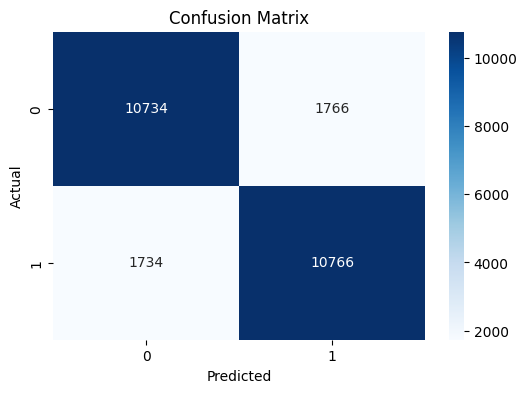

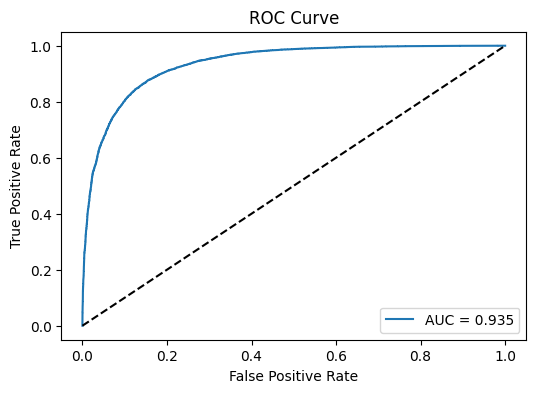

In [105]:
#Evaluation Metric for the test set

y_true_cnn_final = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs_cnn_final = cnn_model_final.predict(test_ds)
y_pred_cnn_tuned_final = (y_pred_probs_cnn_final > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true_cnn_final, y_pred_cnn_tuned_final))

final_f1 = f1_score(y_true_cnn_final,y_pred_cnn_tuned_final)
print(f"\n Final F1 Score on the Test set:{final_f1:.4f}")


# Confusion Matrix
cm_cnn_tuned_final = confusion_matrix(y_true_cnn_final, y_pred_cnn_tuned_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn_tuned_final, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#ROC AUC Curve

fpr_cnn_final, tpr_cnn_final, thresholds_cnn_final = roc_curve(y_true_cnn_final, y_pred_probs_cnn_final)
roc_auc_cnn_final = auc(fpr_cnn_final, tpr_cnn_final)

plt.figure(figsize=(6,4))
plt.plot(fpr_cnn_final, tpr_cnn_final, label=f"AUC = {roc_auc_cnn_final:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Citations:
TensorFlow Hub. (n.d.). BERT uncased English preprocessing model. https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

TensorFlow Hub. (n.d.). Small BERT: Uncased L-4 H-512 A-8. https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1

Devlin, J., Chang, M.‑W., Lee, K., & Toutanova, K. (2019). BERT: Pre‑training of deep bidirectional transformers for language understanding. Proceedings of NAACL‑HLT. https://arxiv.org/abs/1810.04805

TensoFlow:
Abadi, M., et al. (2016). TensorFlow: Large‑scale machine learning on heterogeneous systems. https://www.tensorflow.org/

TensorFlow Text:

TensorFlow Text. (n.d.). https://www.tensorflow.org/text